# EJERCICIO FINAL PYSPARK (DOCKER + KAFKA + PYSPARK)

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *
from pyspark.sql import functions as F
from pyspark.sql.window import Window


## Creamos la sesión de spark

In [2]:
spark = (
    SparkSession.builder
        .appName("ProyectoIoT")
        .getOrCreate()
)
spark

spark.readStream
Indica que vamos a leer datos en modo streaming, es decir, datos que llegan continuamente.

.format("kafka")
Le decimos a Spark que la fuente de datos de streaming será Kafka.

.option("kafka.bootstrap.servers", "kafka:9092")
Especifica la dirección del clúster Kafka al que conectarse.
En este caso "kafka" es el nombre del contenedor Docker y 9092 es el puerto del broker.

.option("subscribe", "sensores")
Indica el topic de Kafka del que queremos leer mensajes → "sensores".

.option("startingOffsets", "latest")
Define desde qué punto empezar a leer:

"latest" → solo recibe mensajes nuevos, enviados después de iniciar el streaming.

"earliest" sería para leer todos los mensajes antiguos también.

.load()
Ejecuta la configuración y crea un DataFrame de streaming, donde cada fila representa un mensaje recibido desde Kafka.

In [3]:
raw_df = (
    spark.readStream
         .format("kafka")
         .option("kafka.bootstrap.servers", "kafka:9092")  # <-- nombre del contenedor
         .option("subscribe", "sensores")
         .option("startingOffsets", "latest")
         .load()
)


Este bloque transforma los mensajes de Kafka en un formato que Spark puede procesar:

Define la estructura de los datos que esperamos recibir (sensor, valor, temperatura, humedad, estado, timestamp y UUID).

Convierte el JSON recibido en columnas individuales para poder trabajar con cada campo.

Crea una columna de tiempo (event_time) a partir del timestamp original para poder usarlo en ventanas y agregaciones temporales.

In [4]:
schema = StructType([
    StructField("sensor_id", StringType()),
    StructField("value", DoubleType()),
    StructField("temperature", DoubleType()),
    StructField("humidity", DoubleType()),
    StructField("status", StringType()),
    StructField("timestamp", DoubleType()),
    StructField("uuid", StringType())
])

df = raw_df.select(
    from_json(col("value").cast("string"), schema).alias("data")
).select("data.*")

df = df.withColumn("event_time", col("timestamp").cast("timestamp"))


Este bloque realiza agregaciones por ventana de tiempo sobre el DataFrame de streaming:

Define un watermark de 1 minuto para indicar a Spark hasta qué punto los datos antiguos se pueden considerar válidos. Esto ayuda a manejar retrasos y datos tardíos.

Agrupa los datos cada 30 segundos por sensor (sensor_id).

Calcula estadísticas dentro de cada ventana: promedio de valor, temperatura y humedad, y cuenta el número de eventos recibidos.

El resultado es un DataFrame de streaming con resúmenes temporales por sensor listo para análisis o escritura.

In [5]:
agg_df = (
    df
    .withWatermark("event_time", "1 minute")   # ← IMPORTANTE
    .groupBy(
        window(col("event_time"), "30 seconds"),
        col("sensor_id")
    )
    .agg(
        avg("value").alias("avg_value"),
        avg("temperature").alias("avg_temp"),
        avg("humidity").alias("avg_humidity"),
        count("*").alias("num_events")
    )
)


Este bloque escribe los resultados del streaming en archivos Parquet de manera continua:

Define la carpeta de salida donde se guardarán los archivos Parquet (resultados/).

Usa un checkpoint (chk/) para que Spark recuerde qué datos ya procesó y pueda reiniciar de forma segura en caso de fallo.

Modo append: los nuevos datos se agregan continuamente a los archivos existentes.

Inicia el streaming, haciendo que las agregaciones se escriban en tiempo real mientras llegan nuevos datos.

El resultado es un conjunto de archivos Parquet que refleja las métricas agregadas por ventana y por sensor.

In [6]:
parquet_query = (
    agg_df
    .writeStream
    .format("parquet")
    .option("path", "resultados/")
    .option("checkpointLocation", "chk/")
    .outputMode("append")
    .start()
)


A partir de aquí, te toca a ti, sigue las cuestiones planteadas en el Readme y completa el notebook. Despues guardatelo con los outputs de las celdas y súbelo al repo. Mucha suerte que ya lo teneis ;)

### Ejercicio 1

In [7]:
df.printSchema()
agg_df.printSchema()
df_resultados = spark.read.parquet("resultados/")
print(f"Filas guardadas: {df_resultados.count()}")
df_resultados.select("sensor_id").distinct().show()

root
 |-- sensor_id: string (nullable = true)
 |-- value: double (nullable = true)
 |-- temperature: double (nullable = true)
 |-- humidity: double (nullable = true)
 |-- status: string (nullable = true)
 |-- timestamp: double (nullable = true)
 |-- uuid: string (nullable = true)
 |-- event_time: timestamp (nullable = true)

root
 |-- window: struct (nullable = false)
 |    |-- start: timestamp (nullable = true)
 |    |-- end: timestamp (nullable = true)
 |-- sensor_id: string (nullable = true)
 |-- avg_value: double (nullable = true)
 |-- avg_temp: double (nullable = true)
 |-- avg_humidity: double (nullable = true)
 |-- num_events: long (nullable = false)

Filas guardadas: 796
+---------+
|sensor_id|
+---------+
|       S4|
|       S3|
|       S2|
|       S1|
+---------+



### Ejercicio 2

In [8]:
df_resultados = spark.read.parquet("resultados/")
sensoresNuevaColumnaDF = df_resultados.withColumn("temp_hum_ratio", col("avg_temp") / col("avg_humidity"))
sensoresNuevaColumnaDF.select(
    max("temp_hum_ratio").alias("Maximo"),
    min("temp_hum_ratio").alias("Minimo"),
    avg("temp_hum_ratio").alias("Media")
).show()

+---------------+-------------------+------------------+
|         Maximo|             Minimo|             Media|
+---------------+-------------------+------------------+
|3.5546410608139|0.39907396319802013|1.0095047160384245|
+---------------+-------------------+------------------+



### Ejercicio 3

In [9]:
df_resultados = spark.read.parquet("resultados/")
df_filtrado = df_resultados.filter(
    (col("avg_humidity") > 50) & 
    (col("num_events") > 9 ) & 
    (col("avg_temp") > 55 ) &
    (col("sensor_id").isin("S1", "S2", "S3", "S4"))
)
total_cumplen = df_filtrado.count()
print(f"Número de registros que cumplen todas las condiciones: {total_cumplen}")
df_resultados.show(5)
df_filtrado.show(5)

Número de registros que cumplen todas las condiciones: 64
+--------------------+---------+------------------+-----------------+------------------+----------+
|              window|sensor_id|         avg_value|         avg_temp|      avg_humidity|num_events|
+--------------------+---------+------------------+-----------------+------------------+----------+
|{2025-12-14 22:16...|       S4|36.934000000000005|           56.665|52.418000000000006|        10|
|{2025-12-14 22:16...|       S1|            23.946|            66.17| 50.41799999999999|         5|
|{2025-12-14 23:16...|       S3|            24.924|           43.476|            49.462|         5|
|{2025-12-14 23:16...|       S1|          31.00875|49.75874999999999|57.792500000000004|         8|
|{2025-12-14 22:30...|       S1|31.316999999999997|55.15599999999999| 56.64300000000001|        10|
+--------------------+---------+------------------+-----------------+------------------+----------+
only showing top 5 rows

+----------------

### Ejercicio 4

In [10]:
df_resultados = spark.read.parquet("resultados/")
df_stats = df_resultados.groupBy("sensor_id").agg(
    avg("avg_temp").alias("Media_Global"),
    max("avg_temp").alias("Temp_Maxima_Registrada"),
    count("window").alias("Total_Ventanas")
)
df_stats.show()
print("--- Sensor con mayor media ---")
df_stats.orderBy(col("Media_Global").desc()).show(1)
print("--- Sensor con temperatura máxima ---")
df_stats.orderBy(col("Temp_Maxima_Registrada").desc()).show(1)

+---------+------------------+----------------------+--------------+
|sensor_id|      Media_Global|Temp_Maxima_Registrada|Total_Ventanas|
+---------+------------------+----------------------+--------------+
|       S4| 55.08812055713689|                 77.74|           199|
|       S3| 54.52380979322186|     74.27833333333334|           199|
|       S2|54.314815222047635|     71.52000000000001|           199|
|       S1| 54.31655677195502|     80.21166666666666|           199|
+---------+------------------+----------------------+--------------+

--- Sensor con mayor media ---
+---------+-----------------+----------------------+--------------+
|sensor_id|     Media_Global|Temp_Maxima_Registrada|Total_Ventanas|
+---------+-----------------+----------------------+--------------+
|       S4|55.08812055713689|                 77.74|           199|
+---------+-----------------+----------------------+--------------+
only showing top 1 row

--- Sensor con temperatura máxima ---
+---------+---

### Ejercicio 5

In [11]:
df_resultados = spark.read.parquet("resultados/")
ventana_sensor = Window.partitionBy("sensor_id").orderBy(col("avg_value").desc())
df_ranked = df_resultados.withColumn("ranking", row_number().over(ventana_sensor))
df_maximos_por_sensor = df_ranked.filter(col("ranking") == 1)
print("--- Registro con mayor avg_value por cada sensor ---")
df_maximos_por_sensor.select("sensor_id", "avg_value", "window").show(truncate=False)
print("--- GANADOR GLOBAL: Sensor con el valor más alto de todos ---")
df_maximos_por_sensor.orderBy(col("avg_value").desc()).show(1)

--- Registro con mayor avg_value por cada sensor ---
+---------+-----------------+------------------------------------------+
|sensor_id|avg_value        |window                                    |
+---------+-----------------+------------------------------------------+
|S1       |46.7675          |{2025-12-14 22:15:30, 2025-12-14 22:16:00}|
|S2       |48.985           |{2025-12-14 22:32:00, 2025-12-14 22:32:30}|
|S3       |47.59            |{2025-12-14 22:06:30, 2025-12-14 22:07:00}|
|S4       |41.18000000000001|{2025-12-14 22:58:00, 2025-12-14 22:58:30}|
+---------+-----------------+------------------------------------------+

--- GANADOR GLOBAL: Sensor con el valor más alto de todos ---
+--------------------+---------+---------+--------+------------+----------+-------+
|              window|sensor_id|avg_value|avg_temp|avg_humidity|num_events|ranking|
+--------------------+---------+---------+--------+------------+----------+-------+
|{2025-12-14 22:32...|       S2|   48.985|  63.8

### Ejercicio 6

In [12]:
df_resultados = spark.read.parquet("resultados/")
datos_sensores = [
    ("S1", "Laboratorio_Central", "Alta_Precision"),
    ("S2", "Almacen_Frio", "Estandar"),
    ("S3", "Exterior_Patio", "Resistente_Agua"),
    ("S4", "Oficina_Principal", "Estandar"),
    ("S2", "Legacy_Lab", "Antiguo")
]
columnas = ["sensor_id", "ubicacion", "tipo_sensor"]
df_info_sensores = spark.createDataFrame(datos_sensores, columnas)
df_unido = df_resultados.join(df_info_sensores, on="sensor_id", how="left")
df_unido.show(5)

+---------+--------------------+------------------+------------------+------------------+----------+-------------------+---------------+
|sensor_id|              window|         avg_value|          avg_temp|      avg_humidity|num_events|          ubicacion|    tipo_sensor|
+---------+--------------------+------------------+------------------+------------------+----------+-------------------+---------------+
|       S4|{2025-12-14 22:16...|36.934000000000005|            56.665|52.418000000000006|        10|  Oficina_Principal|       Estandar|
|       S4|{2025-12-14 22:30...|24.986666666666665|54.078333333333326| 67.24333333333333|         6|  Oficina_Principal|       Estandar|
|       S3|{2025-12-14 23:16...|            24.924|            43.476|            49.462|         5|     Exterior_Patio|Resistente_Agua|
|       S1|{2025-12-14 22:16...|            23.946|             66.17| 50.41799999999999|         5|Laboratorio_Central| Alta_Precision|
|       S1|{2025-12-14 23:16...|         

### Ejercicio 7

In [13]:
df_resultados = spark.read.parquet("resultados/")
df_temporal = df_resultados.withColumn(
    "hora_truncada", 
    date_trunc("hour", col("window.start"))
)
df_agrupado = df_temporal.groupBy("hora_truncada").agg(
    count("*").alias("ventanas_por_unidad"),
    avg("avg_humidity").alias("humedad_media")
)
df_agrupado.orderBy("hora_truncada").show(truncate=False)

+-------------------+-------------------+------------------+
|hora_truncada      |ventanas_por_unidad|humedad_media     |
+-------------------+-------------------+------------------+
|2025-12-14 21:00:00|12                 |52.427131764069266|
|2025-12-14 22:00:00|480                |55.13560536373349 |
|2025-12-14 23:00:00|304                |55.46074626159658 |
+-------------------+-------------------+------------------+



### Ejercicio 8

In [14]:
df_resultados = spark.read.parquet("resultados/")
df_reparticionado = df_resultados.repartition("sensor_id")
df_con_particion = df_reparticionado.withColumn("partition_id", spark_partition_id())
df_distribucion = df_con_particion.groupBy("partition_id").agg(
    count("*").alias("num_registros")
)
df_distribucion.orderBy("partition_id").show()
df_con_particion.select("sensor_id", "partition_id").distinct().orderBy("partition_id").show()

+------------+-------------+
|partition_id|num_registros|
+------------+-------------+
|           0|          796|
+------------+-------------+

+---------+------------+
|sensor_id|partition_id|
+---------+------------+
|       S4|           0|
|       S3|           0|
|       S2|           0|
|       S1|           0|
+---------+------------+



### Ejercicio 9

In [15]:
df_resultados = spark.read.parquet("resultados/")
umbral_superior = 60
umbral_inferior = 10
df_anomalias = df_resultados.filter(
    (col("avg_temp") > umbral_superior) | (col("avg_temp") < umbral_inferior)
)
total_anomalias = df_anomalias.count()
print(f"Total de registros anómalos detectados: {total_anomalias}")
ranking_anomalias = df_anomalias.groupBy("sensor_id") \
    .agg(count("*").alias("conteo_anomalias")) \
    .orderBy(col("conteo_anomalias").desc())
print("--- Sensores con más anomalías ---")
ranking_anomalias.show()

Total de registros anómalos detectados: 190
--- Sensores con más anomalías ---
+---------+----------------+
|sensor_id|conteo_anomalias|
+---------+----------------+
|       S4|              50|
|       S3|              49|
|       S2|              48|
|       S1|              43|
+---------+----------------+



### Ejercicio 10

In [18]:
df_resultados = spark.read.parquet("resultados/")
df_score = df_resultados.withColumn(
    "puntuacion_final", 
    (col("avg_value") * 0.4) + (col("avg_temp") * 0.4) + (col("avg_humidity") * 0.2)
)
ganador = df_score.orderBy(col("puntuacion_final").desc()).select("sensor_id", "puntuacion_final").first()
print(f"¿Qué sensor obtiene la puntuación más alta? -> {ganador['sensor_id']}")
print(f"¿Cuál es el valor de dicha puntuación? -> {ganador['puntuacion_final']}")
df_score.select("sensor_id", "avg_value", "avg_temp", "avg_humidity", "puntuacion_final") \
    .orderBy(col("puntuacion_final").desc()) \
    .show(5)

¿Qué sensor obtiene la puntuación más alta? -> S3
¿Cuál es el valor de dicha puntuación? -> 62.77000000000001
+---------+---------+-----------------+-----------------+-----------------+
|sensor_id|avg_value|         avg_temp|     avg_humidity| puntuacion_final|
+---------+---------+-----------------+-----------------+-----------------+
|       S3|    47.59|            72.25|            74.17|62.77000000000001|
|       S2|   48.985|           63.895|           78.645|           60.881|
|       S1|   37.615|78.46166666666666|59.22666666666667|           58.276|
|       S1|  42.5775|           77.635|          47.3225|57.54950000000001|
|       S1|   34.505|80.21166666666666|55.96333333333334|57.07933333333333|
+---------+---------+-----------------+-----------------+-----------------+
only showing top 5 rows



### Ejercicio 11

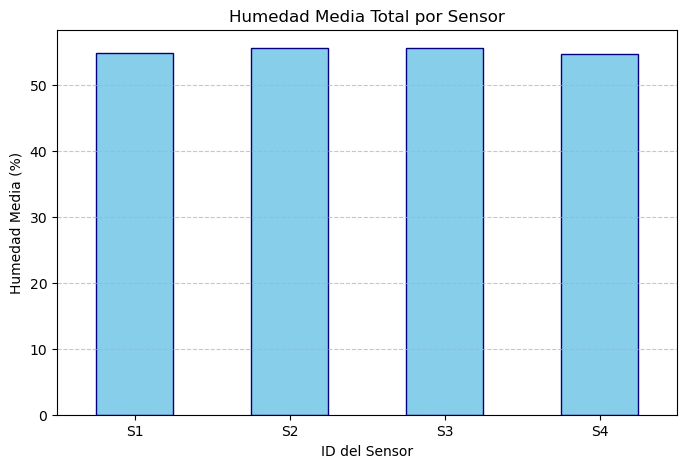

In [20]:
import matplotlib.pyplot as plt
df_resultados = spark.read.parquet("resultados/")
pdf = df_resultados.toPandas()
humedad_por_sensor = pdf.groupby('sensor_id')['avg_humidity'].mean()
plt.figure(figsize=(8, 5))
humedad_por_sensor.plot(kind='bar', color='skyblue', edgecolor='navy')
plt.title('Humedad Media Total por Sensor')
plt.xlabel('ID del Sensor')
plt.ylabel('Humedad Media (%)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()